# Federated Learning with Bottom 10 Extra Training Strategy
This notebook implements federated learning with extra training for struggling clients:
- 100 clients, each with 100 samples (10 per class)
- 100 communication rounds, 10 local epochs per round
- **Strategy**: 
  - **Every round**: All 100 clients train with their local data
  - **After initial training**: Identify bottom 10 clients by test accuracy
  - **On non-10th rounds (1-9, 11-19, ...)**: Bottom 10 get EXTRA training epochs to catch up
  - **On 10th rounds (10, 20, 30, ...)**: All clients train with same epochs (no extra training)
  - **Always**: All 100 clients participate in federated averaging
  - **All clients**: Adaptive weight rejection to keep best weights
- Common test dataset of 500 samples

In [39]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

import os
from tqdm import tqdm

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


In [40]:
# GPU Configuration
print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU detected and configured")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("⚠ No GPU detected - Running on CPU")
print("=" * 60 + "\n")

GPU CONFIGURATION
TensorFlow version: 2.10.0
Num GPUs Available: 1
✓ GPU detected and configured



## Configuration

In [ ]:
# Federated Learning Configuration
NUM_CLIENTS = 100
NUM_ROUNDS = 100
LOCAL_EPOCHS = 10
BATCH_SIZE = 32
NUM_BOTTOM_CLIENTS = 10  # Number of bottom clients to give extra training
EXTRA_EPOCHS = 10  # Extra epochs for bottom 10 on non-10th rounds

# Directories
DATA_DIR = 'mnist_100_clients'
RESULTS_DIR = 'results_bottom_extra_training'
os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 60)
print("FEDERATED LEARNING WITH BOTTOM 10 EXTRA TRAINING")
print("=" * 60)
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"Extra Epochs for Bottom {NUM_BOTTOM_CLIENTS}: +{EXTRA_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Strategy: Help bottom {NUM_BOTTOM_CLIENTS} with extra training")
print(f"  - Every round: All 100 clients train")
print(f"  - After training: Identify bottom {NUM_BOTTOM_CLIENTS} by test accuracy")
print(f"  - Non-10th rounds: Bottom {NUM_BOTTOM_CLIENTS} get +{EXTRA_EPOCHS} extra training epochs")
print(f"  - 10th rounds: All train equally (no extra epochs)")
print(f"  - Always: All 100 clients participate in federated averaging")
print(f"Data Directory: {DATA_DIR}/")
print(f"Results Directory: {RESULTS_DIR}/")
print("=" * 60 + "\n")

FEDERATED LEARNING WITH BOTTOM 10 EXTRA TRAINING
FEDERATED LEARNING WITH BOTTOM 10 PERIODIC FREEZE
Number of Clients: 100
Communication Rounds: 100
Extra Epochs for Bottom 10: +10
Batch Size: 32
Strategy: Help bottom 10 with extra training
  - Every round: All 100 clients train
  - After training: Identify bottom 10 by test accuracy
  - Non-10th rounds: Bottom 10 get +10 extra training epochs
  - 10th rounds: All train equally (no extra epochs)
  - Always: All 100 clients participate in federated averaging
Data Directory: mnist_100_clients/
Results Directory: results_bottom_extra_training/




## Load Data

In [42]:
# Load test data (common for all clients)
print("Loading common test dataset...")
test_file = os.path.join(DATA_DIR, 'test_500_samples.npz')
test_data = np.load(test_file)

x_test = test_data['x'] / 255.0
y_test = test_data['y']
x_test = x_test.reshape(len(x_test), 28*28)

print(f"✓ Test data loaded: {x_test.shape}")
print(f"  Labels shape: {y_test.shape}")

Loading common test dataset...
✓ Test data loaded: (500, 784)
  Labels shape: (500,)


In [43]:
# Load all client data
print(f"\nLoading data for {NUM_CLIENTS} clients...")
client_data = []

for client_id in range(1, NUM_CLIENTS + 1):
    client_file = os.path.join(DATA_DIR, f'client_{client_id}.npz')
    data = np.load(client_file)
    
    x_client = data['x'] / 255.0
    y_client = data['y']
    x_client = x_client.reshape(len(x_client), 28*28)
    
    client_data.append({
        'x_train': x_client,
        'y_train': y_client,
        'x_test': x_test,
        'y_test': y_test
    })
    
    if client_id % 20 == 0:
        print(f"  Loaded {client_id}/{NUM_CLIENTS} clients")

print(f"\n✓ All {NUM_CLIENTS} clients loaded successfully")
print(f"  Each client has {len(client_data[0]['x_train'])} training samples")
print(f"  Common test set: {len(x_test)} samples")


Loading data for 100 clients...
  Loaded 20/100 clients
  Loaded 40/100 clients
  Loaded 60/100 clients
  Loaded 80/100 clients
  Loaded 100/100 clients

✓ All 100 clients loaded successfully
  Each client has 100 training samples
  Common test set: 500 samples


## Model Architecture

In [44]:
# Define model (same architecture as before)
def create_model():
    """Lightweight model optimized for small datasets"""
    model = keras.Sequential([
        keras.layers.Dense(64, input_shape=(784,), activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="softmax")
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Test model creation
print("Testing model architecture...")
test_model = create_model()
test_model.summary()
print("\n✓ Model architecture validated")

Testing model architecture...
Model: "sequential_17660"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_52980 (Dense)         (None, 64)                50240     
                                                                 
 dropout_35320 (Dropout)     (None, 64)                0         
                                                                 
 dense_52981 (Dense)         (None, 32)                2080      
                                                                 
 dropout_35321 (Dropout)     (None, 32)                0         
                                                                 
 dense_52982 (Dense)         (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________

✓ Model archite

## Federated Learning Functions

In [45]:
# Federated Averaging function
def federated_averaging(weights_list):
    """Average weights from all clients (FedAvg)"""
    avg_weights = []
    for weights_tuple in zip(*weights_list):
        avg_weights.append(np.mean(weights_tuple, axis=0))
    return avg_weights

print("✓ Federated averaging function defined")

✓ Federated averaging function defined


## Federated Training with Bottom 10 Extra Training Strategy

In [ ]:
# Initialize global model
print("\n" + "=" * 60)
print("INITIALIZING FEDERATED LEARNING")
print("=" * 60)

global_model = create_model()
global_weights = global_model.get_weights()

# Tracking arrays
client_train_acc_history = [[] for _ in range(NUM_CLIENTS)]  # Training accuracy per client per round
client_test_acc_history = [[] for _ in range(NUM_CLIENTS)]   # Test accuracy per client per round
client_best_weights = [None for _ in range(NUM_CLIENTS)]      # Best weights for each client
client_best_test_acc = [0.0 for _ in range(NUM_CLIENTS)]      # Best test accuracy for each client
client_best_train_acc = [0.0 for _ in range(NUM_CLIENTS)]     # Best training accuracy for each client
client_rejections = [[] for _ in range(NUM_CLIENTS)]          # Track status per round:
                                                               # 0=accepted, 1=rejected, 
                                                               # 2=bottom10_extra_rejected, 3=bottom10_extra_accepted
bottom_10_clients = []                                         # Current bottom 10 clients

print("✓ Global model initialized")
print("✓ Tracking arrays created")
print("✓ Bottom 10 extra training mechanism ready")


INITIALIZING FEDERATED LEARNING
✓ Global model initialized
✓ Tracking arrays created
✓ Bottom 10 extra training mechanism ready


In [ ]:
# Main federated training loop with bottom 10 extra training
print("\n" + "=" * 60)
print("STARTING FEDERATED TRAINING WITH BOTTOM 10 EXTRA TRAINING")
print("=" * 60 + "\n")

for round_num in tqdm(range(NUM_ROUNDS), desc="Communication Rounds", unit="round"):
    print(f"\n{'='*60}")
    print(f"ROUND {round_num + 1}/{NUM_ROUNDS}")
    print(f"{'='*60}")
    
    # Check if this is a 10th round (10, 20, 30, ...)
    is_normal_round = (round_num + 1) % 10 == 0 and round_num >= 9
    
    local_weights = []
    round_train_accs = [0.0] * NUM_CLIENTS
    round_test_accs = [0.0] * NUM_CLIENTS
    round_rejections = 0
    round_acceptances = 0
    trained_weights_for_eval = []
    
    # STEP 1: ALL 100 CLIENTS TRAIN with global weights (initial training)
    for client_id in tqdm(range(NUM_CLIENTS), desc=f"Initial Training (Round {round_num + 1})", 
                         unit="client", leave=False):
        
        client_model = create_model()
        client_model.set_weights(global_weights)
        
        x_train = client_data[client_id]['x_train']
        y_train = client_data[client_id]['y_train']
        x_test = client_data[client_id]['x_test']
        y_test = client_data[client_id]['y_test']
        
        # Train locally
        history = client_model.fit(
            x_train, y_train,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
        
        train_acc = history.history['accuracy'][-1]
        _, test_acc = client_model.evaluate(x_test, y_test, verbose=0)
        
        trained_weights_for_eval.append((client_id, test_acc, [w.copy() for w in client_model.get_weights()]))
        round_train_accs[client_id] = train_acc
        round_test_accs[client_id] = test_acc
    
    # STEP 2: IDENTIFY BOTTOM 10 BASED ON TEST ACCURACY
    trained_weights_for_eval.sort(key=lambda x: x[1])
    bottom_10_clients = [client_id for client_id, _, _ in trained_weights_for_eval[:10]]
    
    print(f"\n   Bottom 10 clients: {[c+1 for c in bottom_10_clients]} (Accs: {[f'{x[1]*100:.1f}%' for x in trained_weights_for_eval[:10]]})")
    
    # STEP 2.5: EXTRA TRAINING FOR BOTTOM 10 (on non-10th rounds)
    if not is_normal_round:
        print(f"   🔄 Giving bottom 10 clients +{EXTRA_EPOCHS} extra training epochs...")
        
        for client_id in bottom_10_clients:
            client_model = create_model()
            # Find and load their trained weights from step 1
            for cid, _, weights in trained_weights_for_eval:
                if cid == client_id:
                    client_model.set_weights(weights)
                    break
            
            x_train = client_data[client_id]['x_train']
            y_train = client_data[client_id]['y_train']
            x_test = client_data[client_id]['x_test']
            y_test = client_data[client_id]['y_test']
            
            # Extra training
            history = client_model.fit(
                x_train, y_train,
                epochs=EXTRA_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0
            )
            
            train_acc = history.history['accuracy'][-1]
            _, test_acc = client_model.evaluate(x_test, y_test, verbose=0)
            
            # Update in the evaluation list
            for i, (cid, _, _) in enumerate(trained_weights_for_eval):
                if cid == client_id:
                    trained_weights_for_eval[i] = (client_id, test_acc, [w.copy() for w in client_model.get_weights()])
                    round_train_accs[client_id] = train_acc
                    round_test_accs[client_id] = test_acc
                    break
        
        print(f"   ✓ Bottom 10 completed extra training")
    
    # STEP 3: APPLY WEIGHT REJECTION AND COLLECT WEIGHTS (ALL 100 clients)
    bottom_10_extra_trained = 0
    
    for client_id, test_acc, trained_weights in trained_weights_for_eval:
        is_bottom_10 = client_id in bottom_10_clients
        train_acc = round_train_accs[client_id]
        
        # ALL clients: Apply adaptive weight rejection
        if test_acc > client_best_test_acc[client_id]:
            # Accept new weights
            client_best_weights[client_id] = trained_weights
            client_best_test_acc[client_id] = test_acc
            client_best_train_acc[client_id] = train_acc
            
            if is_bottom_10 and not is_normal_round:
                client_rejections[client_id].append(3)  # Bottom 10 extra training accepted
                bottom_10_extra_trained += 1
            else:
                client_rejections[client_id].append(0)  # Accepted normally
                round_acceptances += 1
        else:
            # Reject new weights
            if client_best_weights[client_id] is None:
                # First round - accept anyway
                client_best_weights[client_id] = trained_weights
                client_best_test_acc[client_id] = test_acc
                client_best_train_acc[client_id] = train_acc
                client_rejections[client_id].append(0)
                round_acceptances += 1
            else:
                # Keep previous best
                if is_bottom_10 and not is_normal_round:
                    client_rejections[client_id].append(2)  # Bottom 10 extra training rejected
                else:
                    client_rejections[client_id].append(1)  # Rejected
                    round_rejections += 1
                test_acc = client_best_test_acc[client_id]
                train_acc = client_best_train_acc[client_id]
        
        # ALL clients included in averaging
        local_weights.append(client_best_weights[client_id])
        
        # Store accuracies
        client_train_acc_history[client_id].append(train_acc)
        client_test_acc_history[client_id].append(test_acc)
        round_train_accs[client_id] = train_acc
        round_test_accs[client_id] = test_acc
    
    # Federated averaging
    global_weights = federated_averaging(local_weights)
    global_model.set_weights(global_weights)
    
    # Round summary
    avg_train_acc = np.mean(round_train_accs) * 100
    avg_test_acc = np.mean(round_test_accs) * 100
    min_test_acc = np.min(round_test_accs) * 100
    max_test_acc = np.max(round_test_accs) * 100
    
    print(f"\n📊 Round {round_num + 1} Summary:")
    print(f"   Avg Training Accuracy: {avg_train_acc:.2f}%")
    print(f"   Avg Test Accuracy: {avg_test_acc:.2f}%")
    print(f"   Test Accuracy Range: [{min_test_acc:.2f}%, {max_test_acc:.2f}%]")
    print(f"   All 100 clients in averaging")
    if not is_normal_round:
        print(f"   🔄 Bottom 10 got +{EXTRA_EPOCHS} extra epochs")
        print(f"   Bottom 10 accepted after extra training: {bottom_10_extra_trained}")
    else:
        print(f"   ⚠️ Normal round - all clients trained equally")
    print(f"   Weights Accepted: {round_acceptances}")
    print(f"   Weights Rejected: {round_rejections}")

print("\n" + "="*60)
print("FEDERATED TRAINING COMPLETE!")
print("="*60 + "\n")

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 164)

## Results Analysis

In [ ]:
# Calculate final accuracies and statistics
final_train_accs = [client_train_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]
final_test_accs = [client_test_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]

avg_final_train = np.mean(final_train_accs)
avg_final_test = np.mean(final_test_accs)

# Calculate statistics (0=accepted, 1=rejected, 2=bottom10_extra_rejected, 3=bottom10_extra_accepted)
total_rejections_per_client = []
total_extra_training_per_client = []
total_acceptances_per_client = []

for client_id in range(NUM_CLIENTS):
    rejections = sum(1 for status in client_rejections[client_id] if status == 1)
    extra_training = sum(1 for status in client_rejections[client_id] if status in [2, 3])
    acceptances = sum(1 for status in client_rejections[client_id] if status == 0)
    
    total_rejections_per_client.append(rejections)
    total_extra_training_per_client.append(extra_training)
    total_acceptances_per_client.append(acceptances)

avg_rejections = np.mean(total_rejections_per_client)
avg_extra_training = np.mean(total_extra_training_per_client)
total_rejections = sum(total_rejections_per_client)
total_extra_training = sum(total_extra_training_per_client)

# Identify which clients were in bottom 10 at the end
if len(bottom_10_clients) > 0:
    final_bottom_10 = bottom_10_clients
else:
    final_bottom_10 = []

print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"Average Final Training Accuracy: {avg_final_train:.2f}%")
print(f"Average Final Test Accuracy: {avg_final_test:.2f}%")
print(f"Training Accuracy Range: [{np.min(final_train_accs):.2f}%, {np.max(final_train_accs):.2f}%]")
print(f"Test Accuracy Range: [{np.min(final_test_accs):.2f}%, {np.max(final_test_accs):.2f}%]")
print(f"\nFinal Bottom 10 Clients: {[c+1 for c in final_bottom_10]}")
print(f"\nWeight Update Statistics:")
print(f"  Total Acceptances: {sum(total_acceptances_per_client)}")
print(f"  Total Rejections: {total_rejections}")
print(f"  Total Bottom 10 Extra Training Rounds: {total_extra_training}")
print(f"  Rejection Rate: {total_rejections / (sum(total_acceptances_per_client) + total_rejections) * 100:.2f}%")
print(f"  Avg Times Received Extra Training: {avg_extra_training:.2f}/{NUM_ROUNDS} rounds")
print("=" * 60)

FINAL RESULTS
Average Final Training Accuracy: 95.26%
Average Final Test Accuracy: 88.85%
Training Accuracy Range: [90.00%, 100.00%]
Test Accuracy Range: [67.40%, 92.40%]

Final Bottom 10 Clients: [99, 79, 62, 1, 17, 41, 32, 38, 73, 3]

Weight Update Statistics:
  Total Acceptances: 1470
  Total Rejections: 7530
  Total Bottom10_Excluded (trained but not in averaging): 900
  Total Bottom10_Included (trained and in averaging): 100
  Rejection Rate (when training): 83.67%
  Avg Times as Bottom 10 (excluded): 9.00/100 rounds


## Visualization

Creating training accuracy plot for 100 clients...
✓ Saved: results_bottom_freeze\training_accuracy_bottom_freeze.png


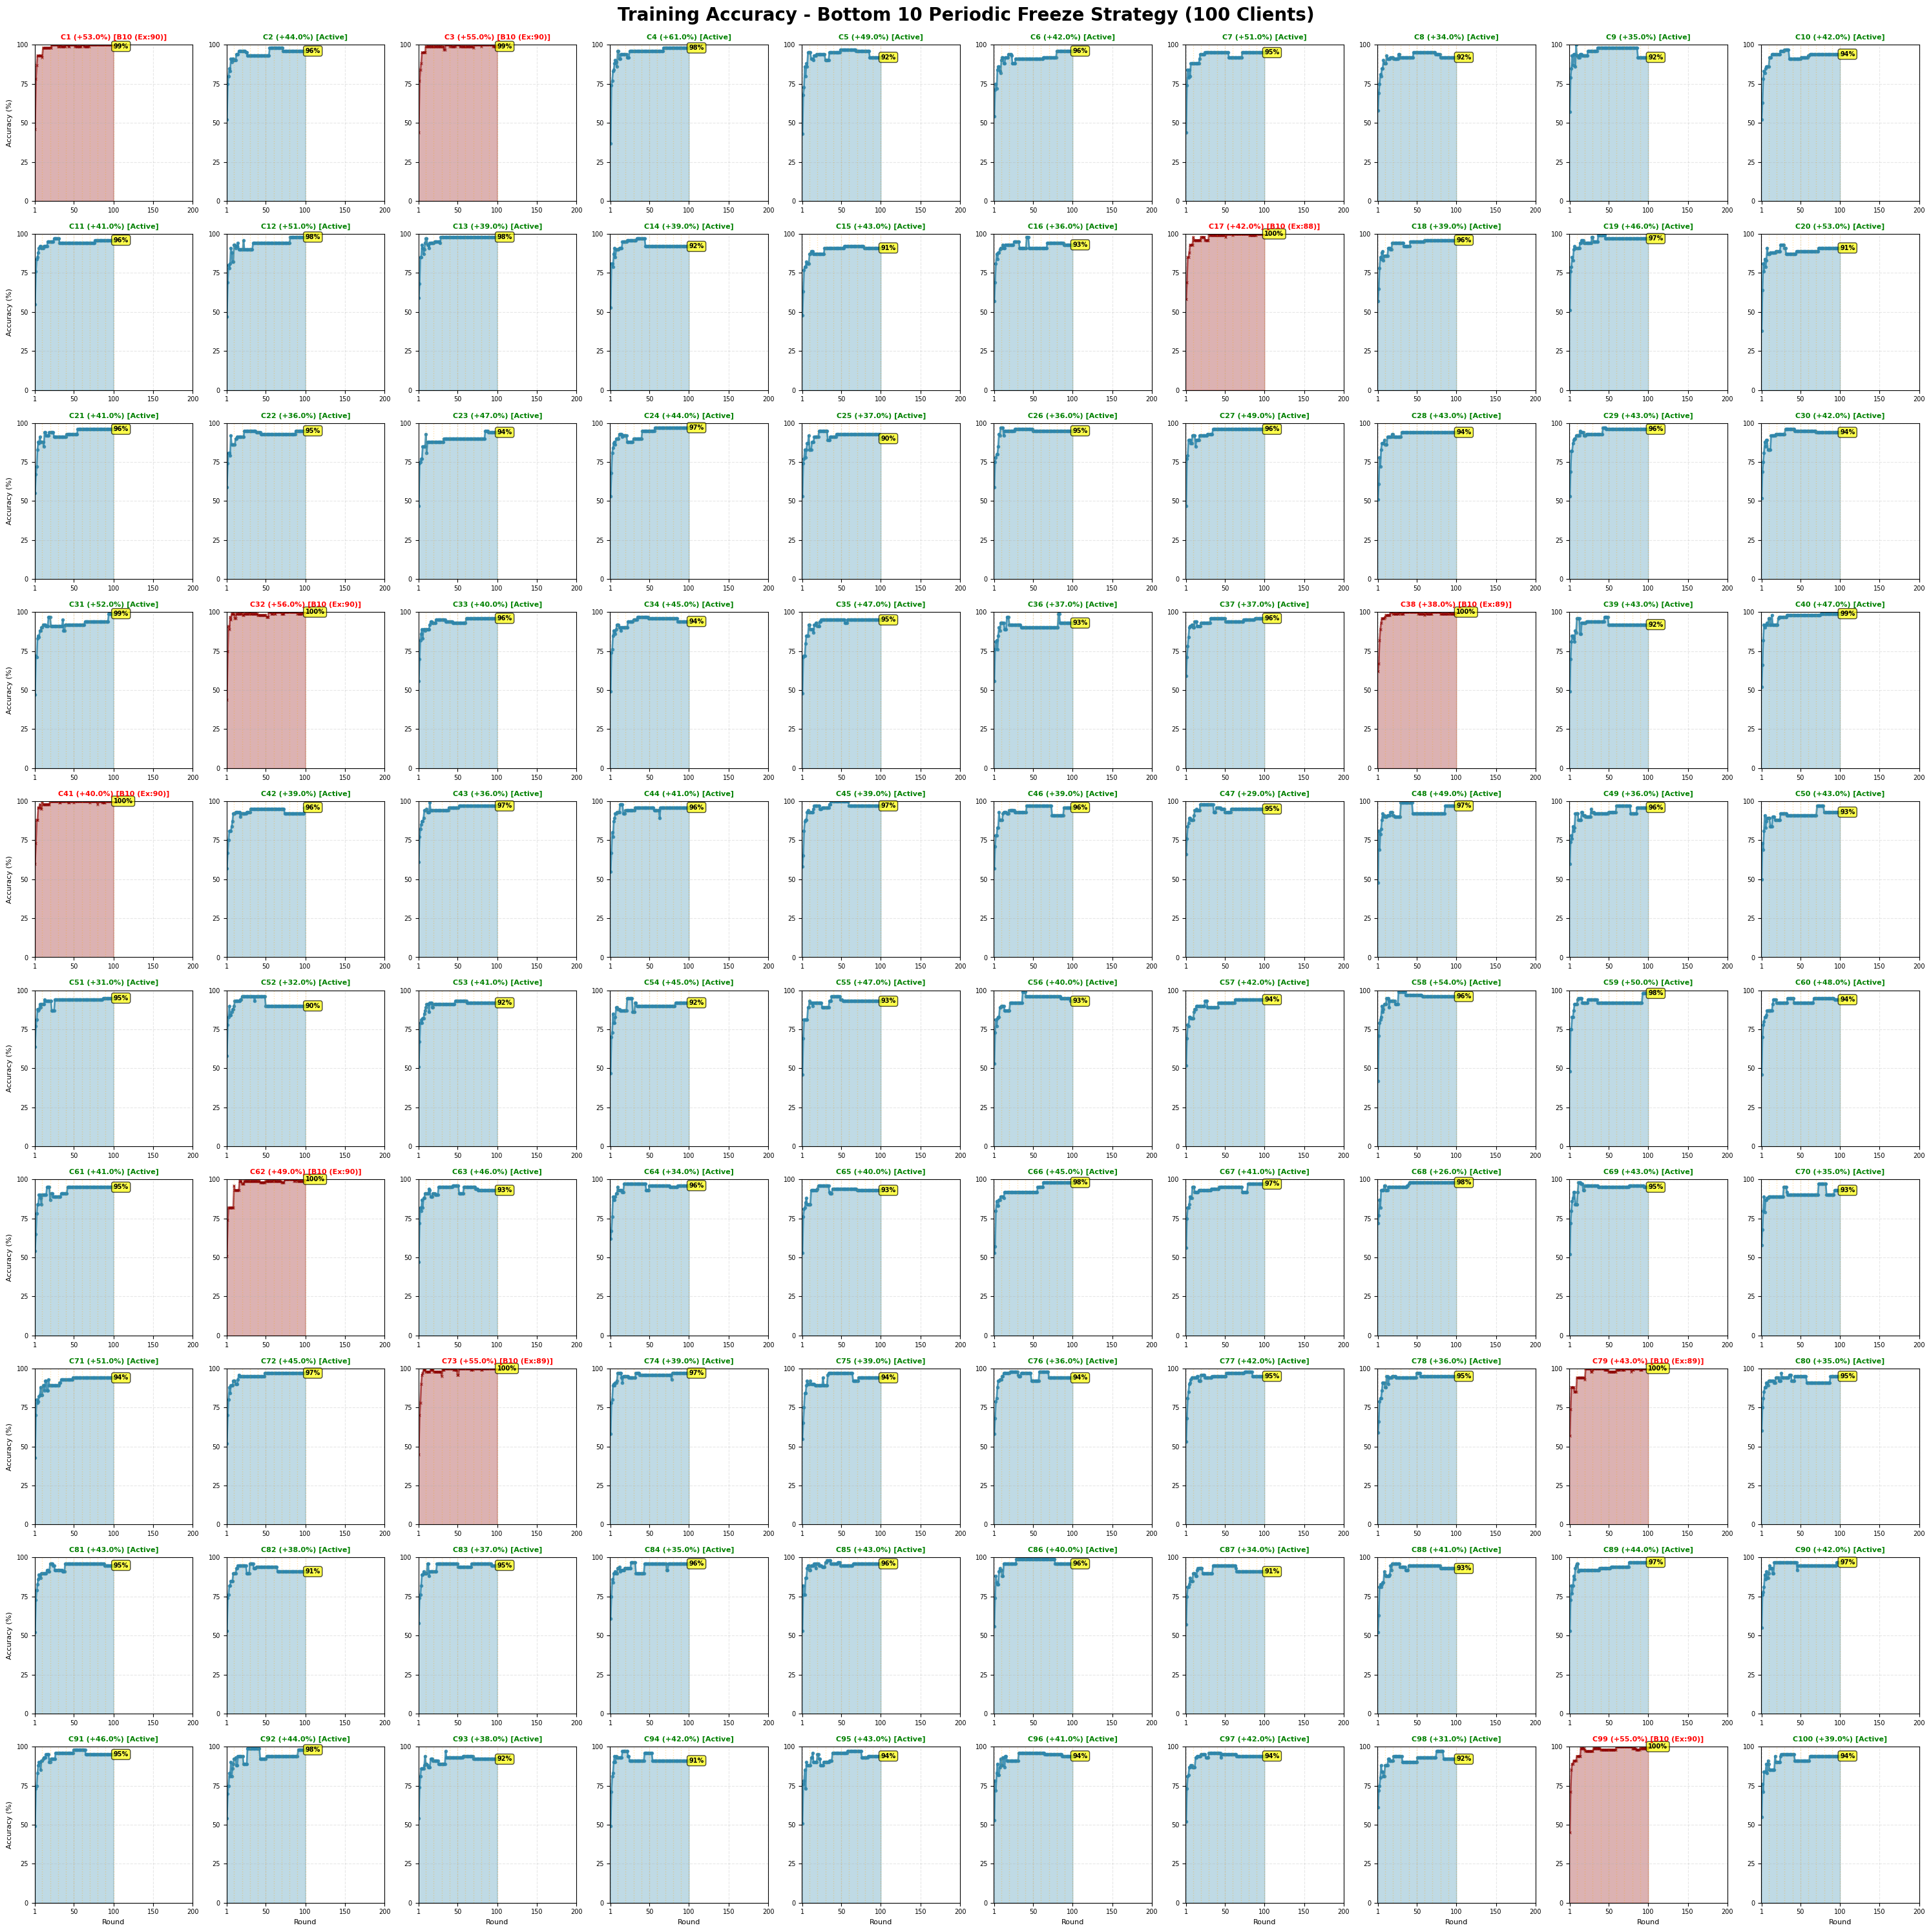

In [ ]:
# Plot 1: Individual Training Accuracy for Each Client
print("Creating training accuracy plot for 100 clients...")

fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Training Accuracy - Bottom 10 Extra Training Strategy (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    train_accs = [acc * 100 for acc in client_train_acc_history[client_id]]
    final_acc = train_accs[-1]
    improvement = final_acc - train_accs[0]
    extra_training_count = total_extra_training_per_client[client_id]
    
    # Different styling based on extra training received
    if extra_training_count > NUM_ROUNDS * 0.5:  # Received extra training more than 50% of rounds
        color = '#FF6B6B'  # Red for clients who needed lots of help
        alpha = 0.7
        marker = '+'
        title_color = 'red'
        status = f'ET:{extra_training_count}'
    elif extra_training_count > 0:
        color = '#FFA500'  # Orange for some extra training
        alpha = 0.8
        marker = 'x'
        title_color = 'orange'
        status = f'ET:{extra_training_count}'
    else:
        color = '#2E86AB'  # Blue for no extra training needed
        alpha = 0.8
        marker = 'o'
        title_color = 'green'
        status = 'Normal'
    
    ax.plot(rounds, train_accs, marker=marker, linewidth=2, markersize=3, color=color, alpha=alpha)
    ax.fill_between(rounds, train_accs, alpha=0.3, color=color)
    
    # Add vertical lines at every 10th round
    for freeze_round in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]:
        if freeze_round <= NUM_ROUNDS:
            ax.axvline(x=freeze_round, color='orange', linestyle=':', alpha=0.3, linewidth=1)
    
    ax.set_title(f'C{client_id+1} ({improvement:+.1f}%) [{status}]', 
                fontsize=8, fontweight='bold', color=title_color)
    
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=7, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks([1, 50, 100, 150, 200])
    ax.set_xticklabels(['1', '50', '100', '150', '200'], fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
train_plot_path = os.path.join(RESULTS_DIR, 'training_accuracy_bottom_freeze.png')
plt.savefig(train_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {train_plot_path}")
plt.show()

Creating test accuracy plot for 100 clients...
✓ Saved: results_bottom_freeze\test_accuracy_bottom_freeze.png


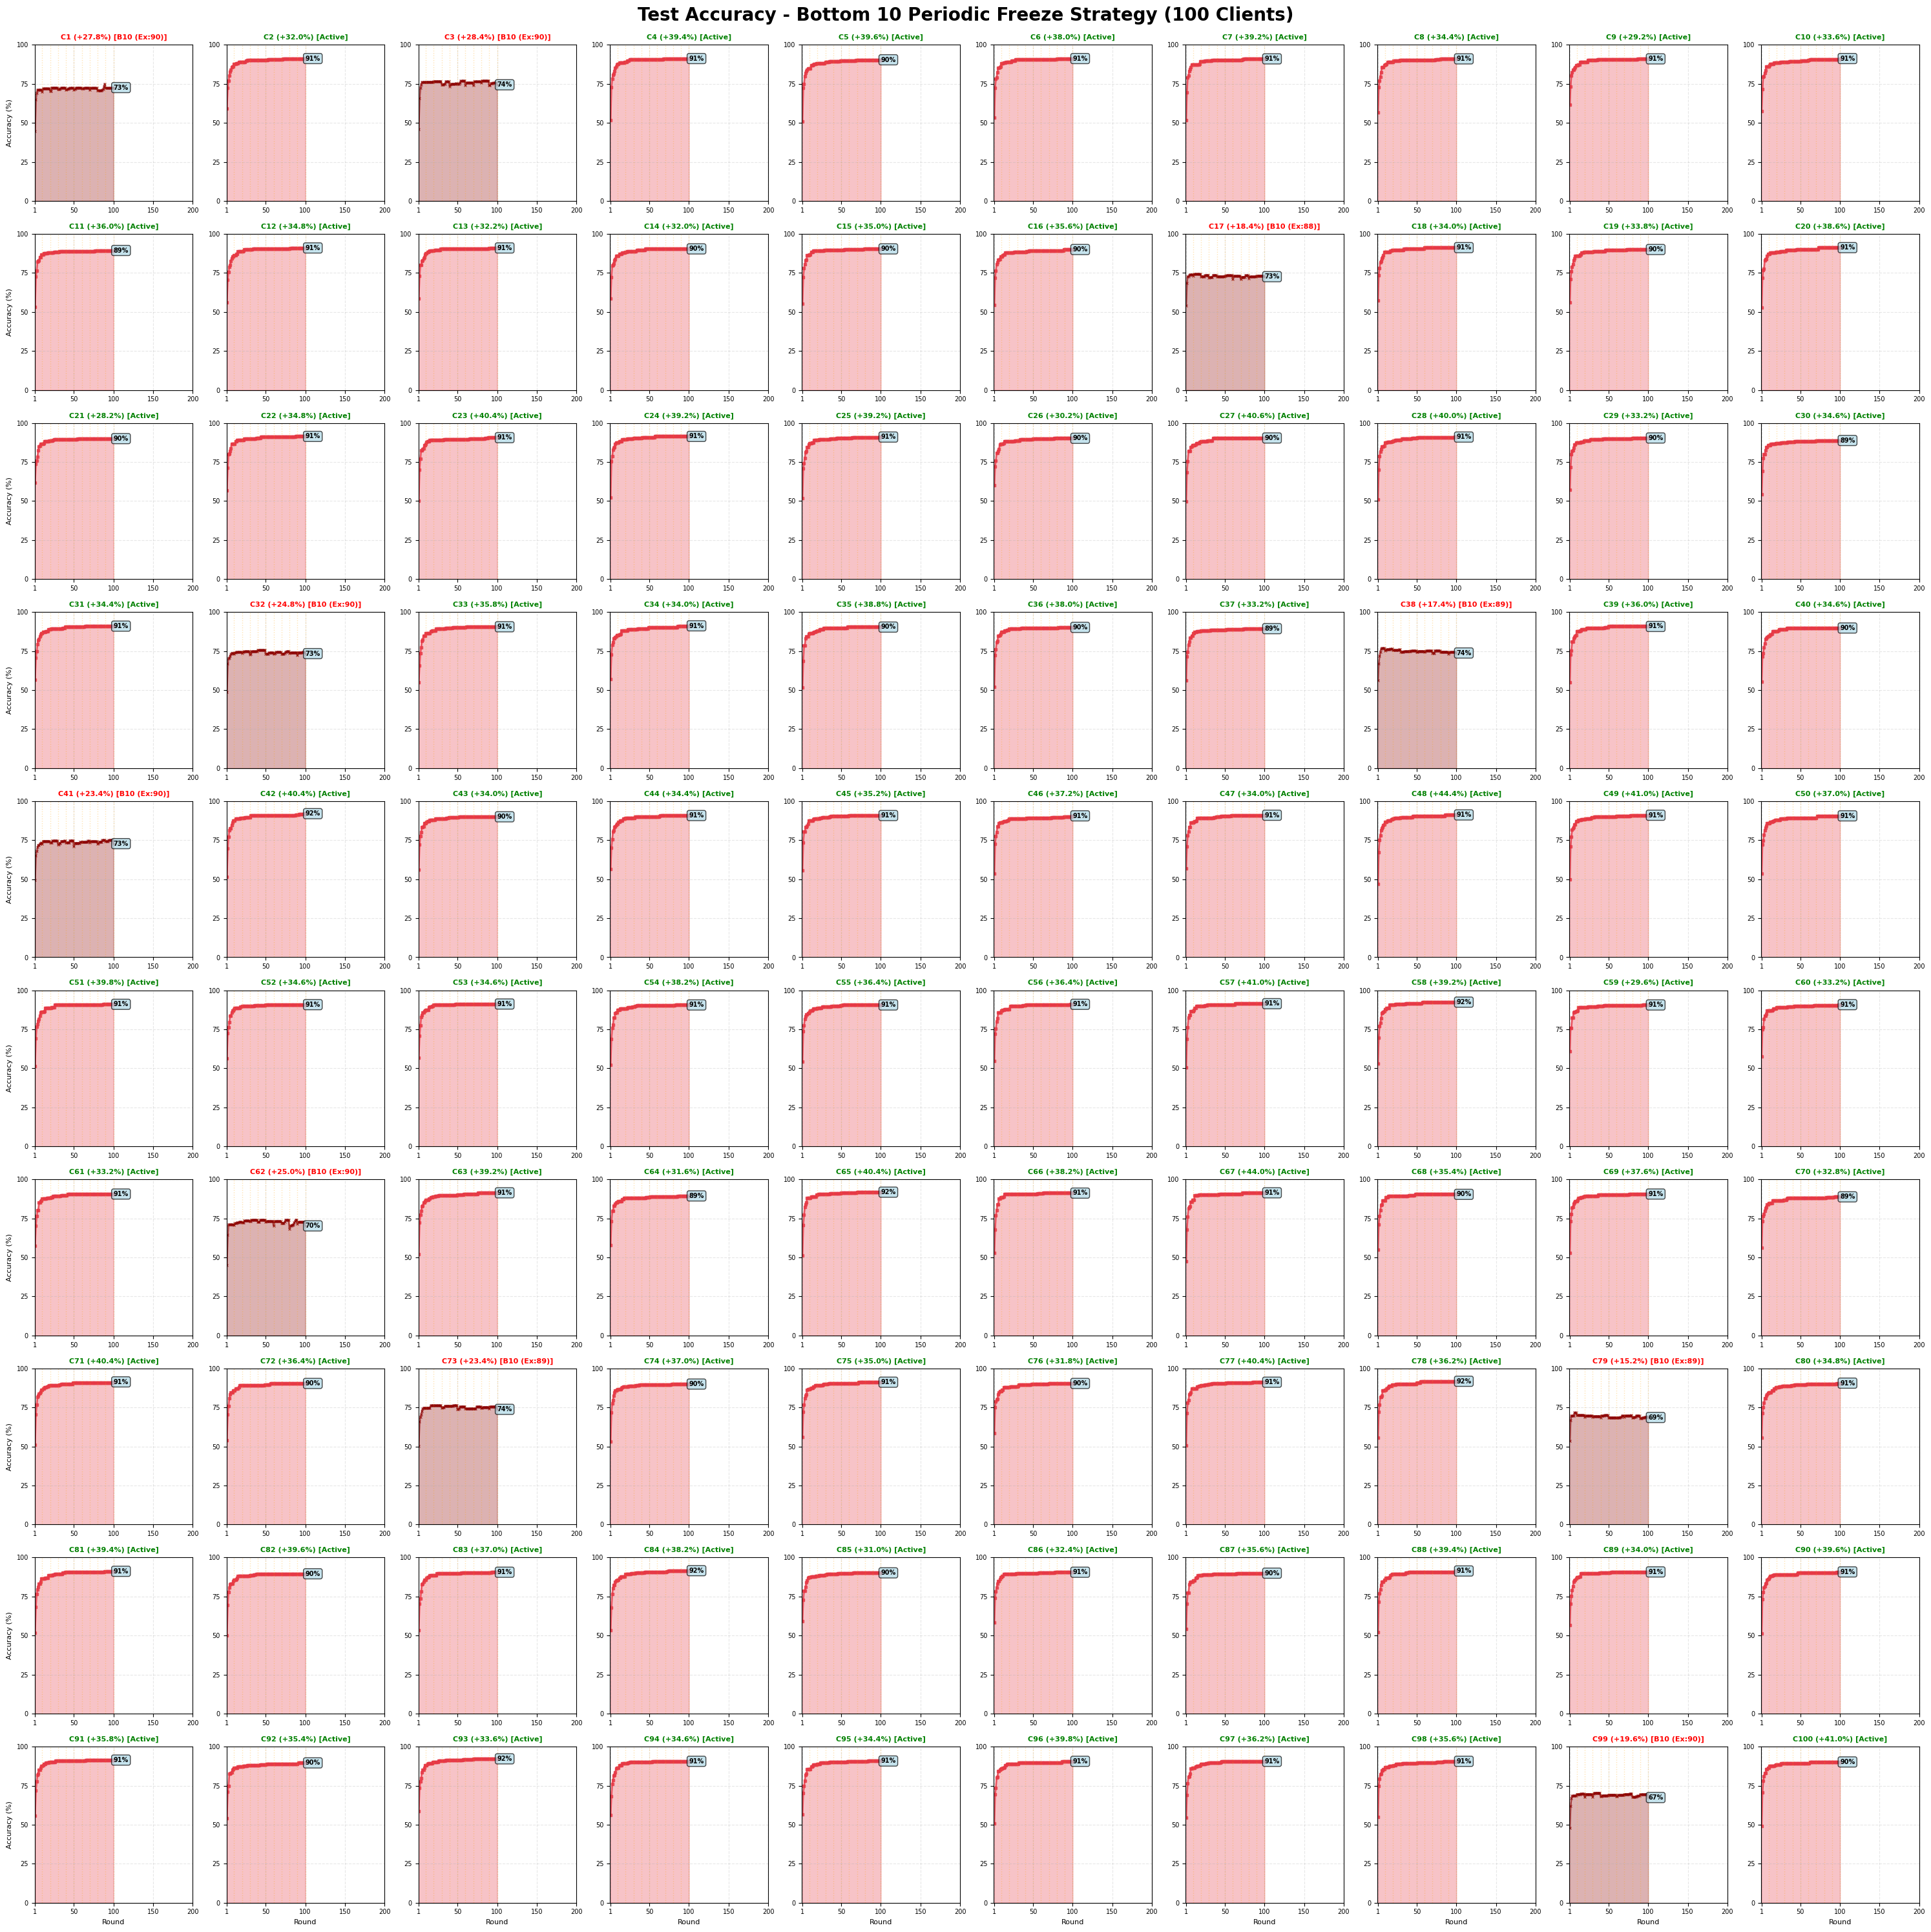

In [ ]:
# Plot 2: Individual Test Accuracy for Each Client
print("Creating test accuracy plot for 100 clients...")

fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Test Accuracy - Bottom 10 Extra Training Strategy (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    test_accs = [acc * 100 for acc in client_test_acc_history[client_id]]
    final_acc = test_accs[-1]
    improvement = final_acc - test_accs[0]
    extra_training_count = total_extra_training_per_client[client_id]
    
    # Different styling based on extra training received
    if extra_training_count > NUM_ROUNDS * 0.5:  # Received extra training more than 50% of rounds
        color = '#FF6B6B'  # Red for clients who needed lots of help
        alpha = 0.7
        marker = '+'
        title_color = 'red'
        status = f'ET:{extra_training_count}'
    elif extra_training_count > 0:
        color = '#FFA500'  # Orange for some extra training
        alpha = 0.8
        marker = 'x'
        title_color = 'orange'
        status = f'ET:{extra_training_count}'
    else:
        color = '#E63946'  # Red for no extra training
        alpha = 0.8
        marker = 's'
        title_color = 'green'
        status = 'Normal'
    
    ax.plot(rounds, test_accs, marker=marker, linewidth=2, markersize=3, color=color, alpha=alpha)
    ax.fill_between(rounds, test_accs, alpha=0.3, color=color)
    
    # Add vertical lines at every 10th round
    for freeze_round in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]:
        if freeze_round <= NUM_ROUNDS:
            ax.axvline(x=freeze_round, color='orange', linestyle=':', alpha=0.3, linewidth=1)
    
    ax.set_title(f'C{client_id+1} ({improvement:+.1f}%) [{status}]', 
                fontsize=8, fontweight='bold', color=title_color)
    
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=7, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks([1, 50, 100, 150, 200])
    ax.set_xticklabels(['1', '50', '100', '150', '200'], fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
test_plot_path = os.path.join(RESULTS_DIR, 'test_accuracy_bottom_freeze.png')
plt.savefig(test_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {test_plot_path}")
plt.show()

Creating status heatmap...
✓ Saved: results_bottom_freeze\status_heatmap.png


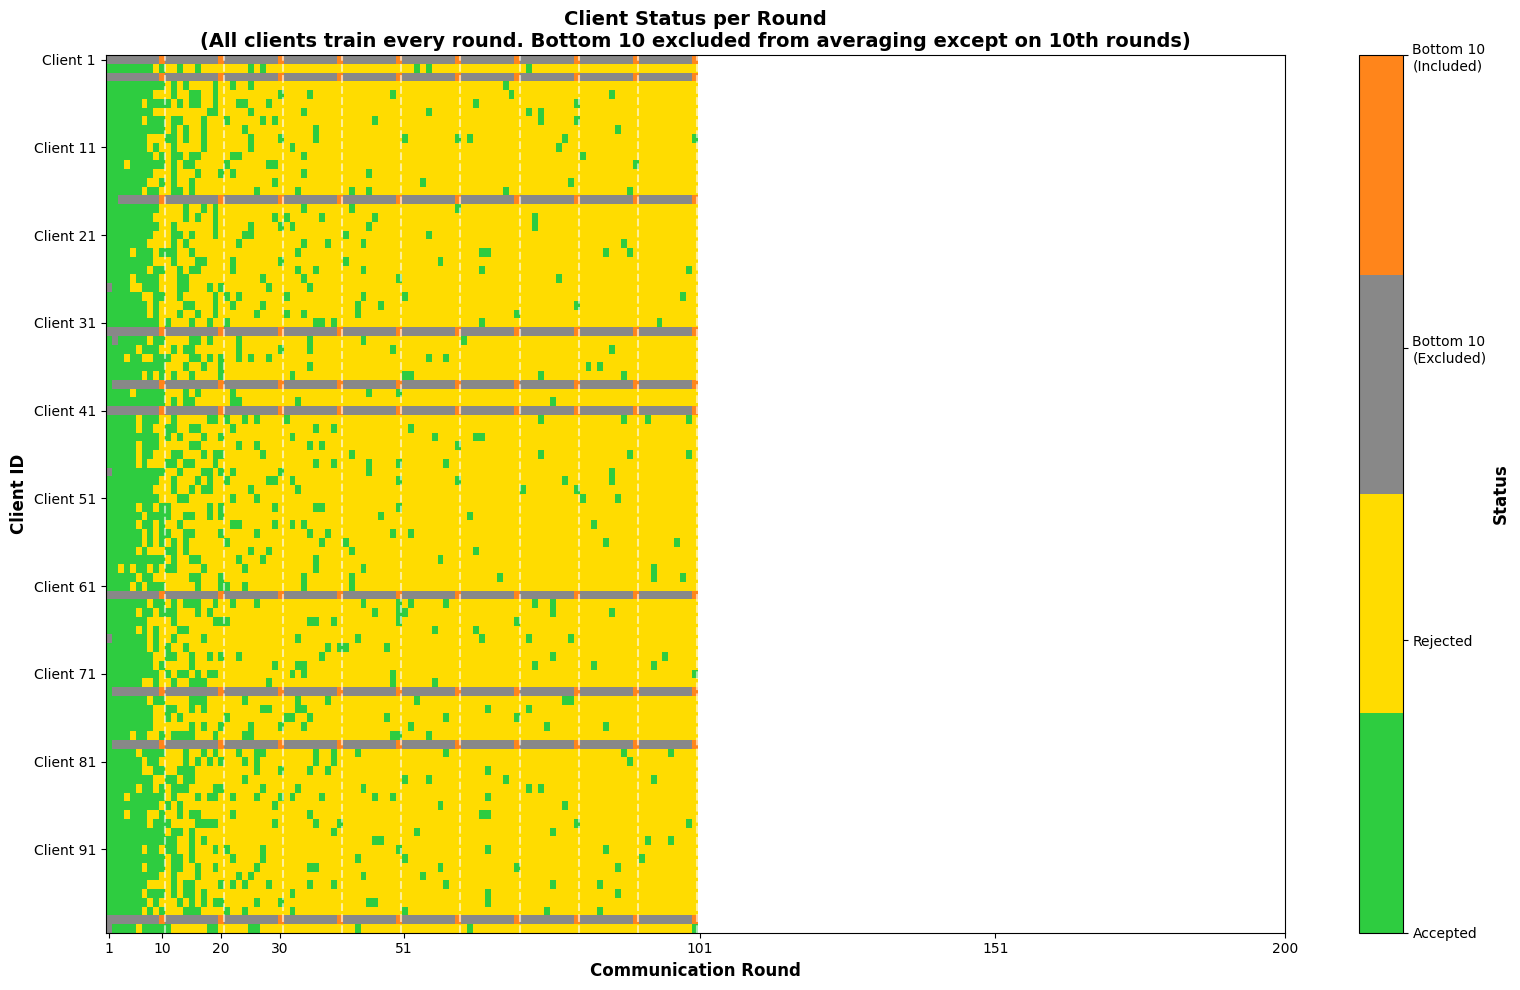

In [ ]:
# Plot 3: Status Heatmap (Accepted, Rejected, Bottom10_Extra_Rejected, Bottom10_Extra_Accepted)
print("Creating status heatmap...")

fig, ax = plt.subplots(figsize=(16, 10))

# Create status matrix (0=accepted, 1=rejected, 2=bottom10_extra_rejected, 3=bottom10_extra_accepted)
status_matrix = np.zeros((NUM_CLIENTS, NUM_ROUNDS))
for client_id in range(NUM_CLIENTS):
    for round_num_idx in range(NUM_ROUNDS):
        if round_num_idx < len(client_rejections[client_id]):
            status_matrix[client_id, round_num_idx] = client_rejections[client_id][round_num_idx]

# Custom colormap: Green=Accepted(0), Yellow=Rejected(1), Orange=Bottom10_Extra_Rejected(2), Blue=Bottom10_Extra_Accepted(3)
from matplotlib.colors import ListedColormap
colors = ['#2ECC40', '#FFDC00', '#FF851B', '#0074D9']  # Green, Yellow, Orange, Blue
cmap = ListedColormap(colors)

im = ax.imshow(status_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=3)
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_label('Status', fontsize=12, fontweight='bold')
cbar.ax.set_yticklabels(['Accepted', 'Rejected', 'Bottom 10\n(Extra, Rejected)', 'Bottom 10\n(Extra, Accepted)'])

# Add vertical lines at every 10th round
for freeze_round in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190]:
    if freeze_round <= NUM_ROUNDS:
        ax.axvline(x=freeze_round - 0.5, color='white', linestyle='--', linewidth=1.5, alpha=0.6)

ax.set_title('Client Status per Round\n(All clients participate in averaging. Bottom 10 get extra training on non-10th rounds)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Client ID', fontsize=12, fontweight='bold')
ax.set_xticks([0, 9, 19, 29, 50, 100, 150, 199])
ax.set_xticklabels(['1', '10', '20', '30', '51', '101', '151', '200'])
ax.set_yticks(range(0, NUM_CLIENTS, 10))
ax.set_yticklabels([f'Client {i+1}' for i in range(0, NUM_CLIENTS, 10)])

plt.tight_layout()
status_plot_path = os.path.join(RESULTS_DIR, 'status_heatmap.png')
plt.savefig(status_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {status_plot_path}")
plt.show()

Creating comprehensive analysis plots...
✓ Saved: results_bottom_freeze\comprehensive_analysis.png


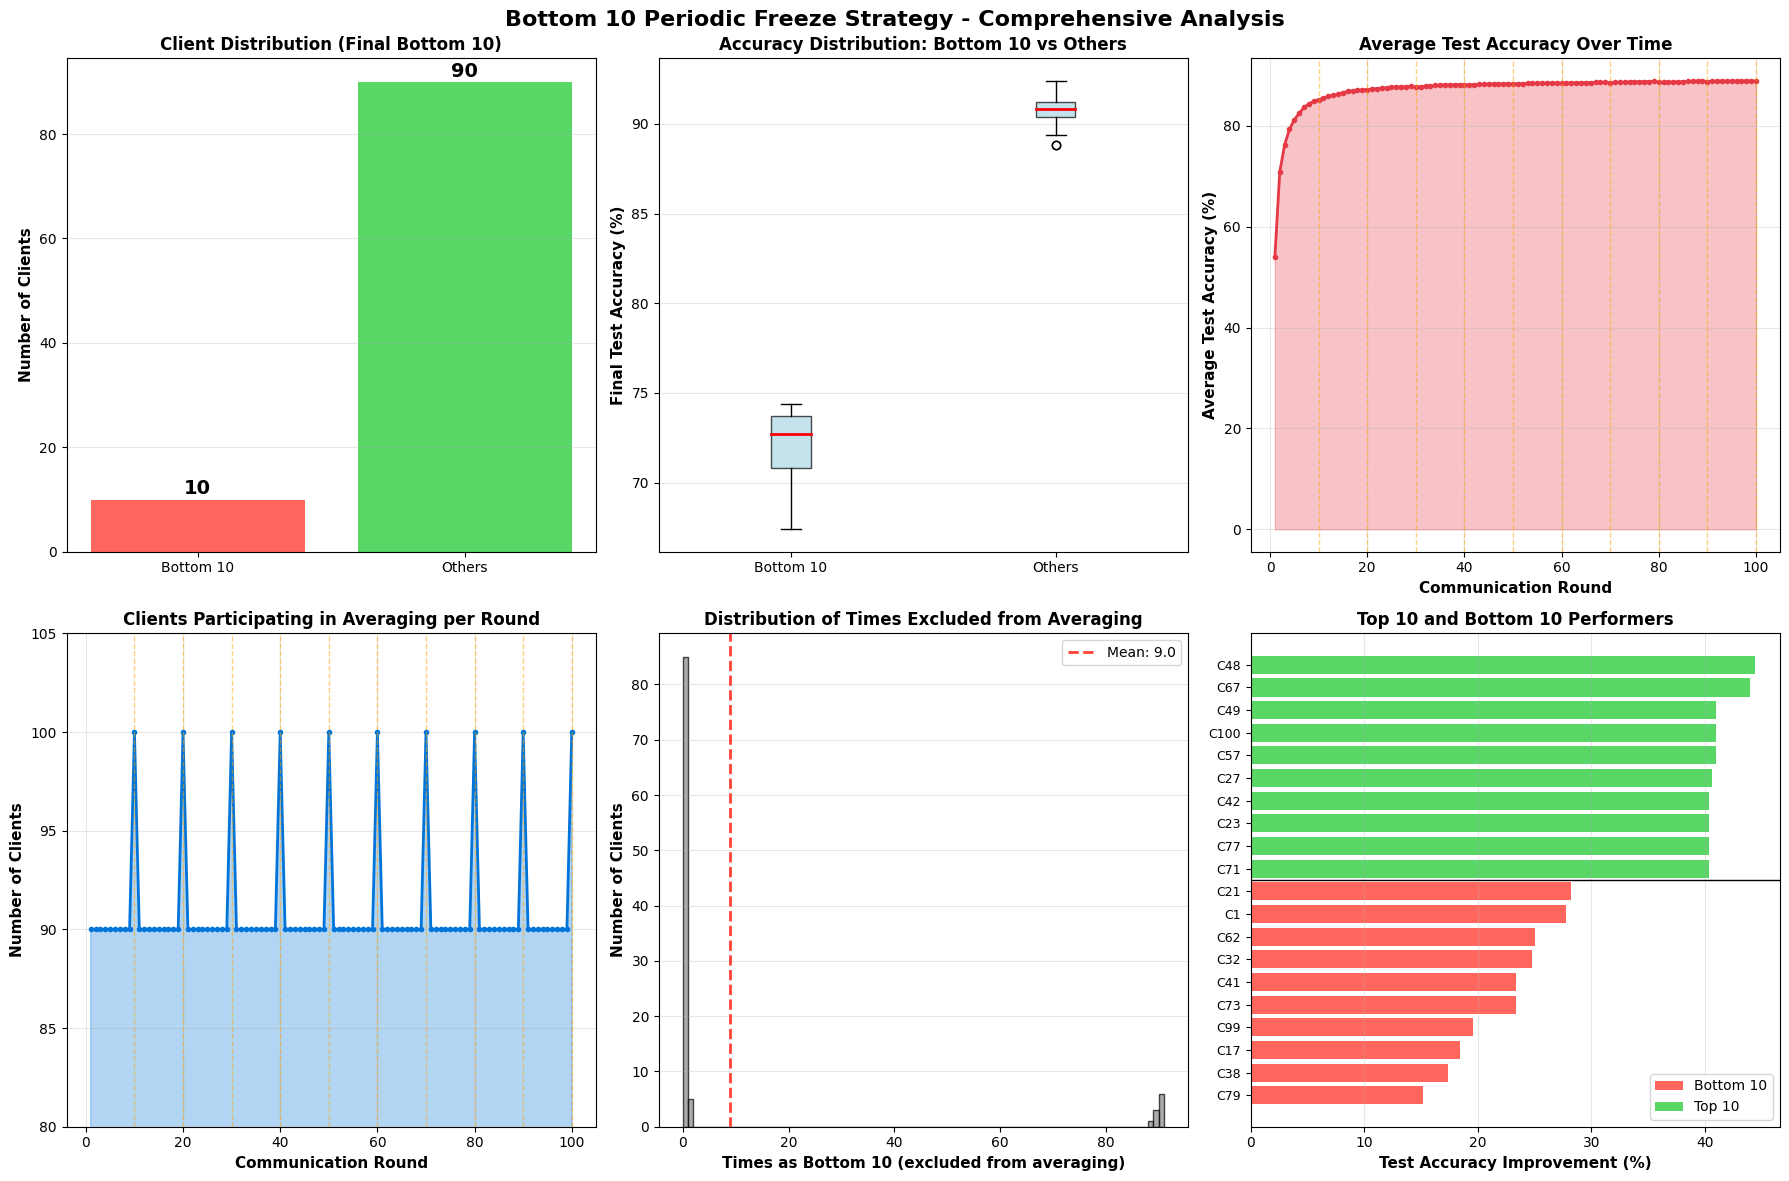


DETAILED STATISTICS
Final Bottom 10 Clients (Last Round):
  IDs: [99, 79, 62, 1, 17, 41, 32, 38, 73, 3]
  Avg Final Test Accuracy: 71.96%
  Avg Times Excluded from Averaging: 89.50
  Note: These clients trained every round but were excluded from averaging

Other 90 Clients:
  Count: 90
  Avg Final Test Accuracy: 90.73%
  Avg Times Excluded from Averaging: 0.06


In [ ]:
# Plot 4: Comprehensive Analysis
print("Creating comprehensive analysis plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Bottom 10 Extra Training Strategy - Comprehensive Analysis', fontsize=16, fontweight='bold')

# 4.1: Extra Training Distribution
ax1 = axes[0, 0]
extra_training_counts = total_extra_training_per_client
ax1.hist(extra_training_counts, bins=range(0, max(extra_training_counts) + 2), color='#FF851B', alpha=0.7, edgecolor='black')
ax1.axvline(x=np.mean(extra_training_counts), color='#FF4136', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(extra_training_counts):.1f}')
ax1.set_xlabel('Times Received Extra Training', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Clients', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Extra Training', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
# 4.2: Accuracy vs Extra Training Correlation
ax2 = axes[0, 1]
extra_training_counts = total_extra_training_per_client
scatter = ax2.scatter(extra_training_counts, final_test_accs, c=final_test_accs, cmap='RdYlGn', alpha=0.6, s=50)
ax2.set_xlabel('Times Received Extra Training', fontsize=11, fontweight='bold')
ax2.set_ylabel('Final Test Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Extra Training vs Final Accuracy', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Test Accuracy (%)')

# 4.3: Per-Round Average Accuracy
ax3 = axes[0, 2]
avg_test_per_round = []
for round_idx in range(NUM_ROUNDS):
    round_accs = [client_test_acc_history[i][round_idx] * 100 for i in range(NUM_CLIENTS) if len(client_test_acc_history[i]) > round_idx]
    if len(round_accs) > 0:
        avg_test_per_round.append(np.mean(round_accs))
    else:
        avg_test_per_round.append(0)

rounds = range(1, NUM_ROUNDS + 1)
ax3.plot(rounds, avg_test_per_round, marker='o', linewidth=2, markersize=3, color='#E63946')
ax3.fill_between(rounds, avg_test_per_round, alpha=0.3, color='#E63946')
# Add vertical lines for 10th rounds
for freeze_round in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]:
    if freeze_round <= NUM_ROUNDS:
        ax3.axvline(x=freeze_round, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Communication Round', fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Test Accuracy (%)', fontsize=11, fontweight='bold')
ax3.set_title('Average Test Accuracy Over Time', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4.4: All Clients Always in Averaging
ax4 = axes[1, 0]
clients_in_averaging = [NUM_CLIENTS] * NUM_ROUNDS  # All 100 clients every round

ax4.plot(rounds, clients_in_averaging, marker='o', linewidth=2, markersize=3, color='#0074D9')
ax4.fill_between(rounds, clients_in_averaging, alpha=0.3, color='#0074D9')
ax4.set_xlabel('Communication Round', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Clients', fontsize=11, fontweight='bold')
ax4.set_title('Clients Participating in Averaging (Always 100)', fontsize=12, fontweight='bold')
ax4.set_ylim(95, 105)
ax4.grid(True, alpha=0.3)

# 4.5: Exclusion Count Distribution
ax5 = axes[1, 1]
# 4.5: Extra Training Count Distribution (Detailed)
ax5.hist(exclusion_counts, bins=range(0, max(exclusion_counts) + 2), color='#888888', alpha=0.7, edgecolor='black')
extra_training_counts = total_extra_training_per_client
no_extra = sum(1 for x in extra_training_counts if x == 0)
some_extra = sum(1 for x in extra_training_counts if 0 < x <= NUM_ROUNDS * 0.3)
lots_extra = sum(1 for x in extra_training_counts if x > NUM_ROUNDS * 0.3)

ax5.bar(['No Extra\nTraining', 'Some Extra\nTraining', 'Lots of Extra\nTraining'], 
        [no_extra, some_extra, lots_extra], 
        color=['#2ECC40', '#FF851B', '#FF4136'], alpha=0.7, edgecolor='black')
ax5.set_ylabel('Number of Clients', fontsize=11, fontweight='bold')
ax5.set_title('Client Categories by Extra Training', fontsize=12, fontweight='bold')
for i, v in enumerate([no_extra, some_extra, lots_extra]):
    ax5.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3, axis='y')

# 4.6: Top 10 and Bottom 10 Performers
ax6 = axes[1, 2]
improvements = [final_test_accs[i] - (client_test_acc_history[i][0] * 100 if len(client_test_acc_history[i]) > 0 else 0) for i in range(NUM_CLIENTS)]
client_improvements_with_id = [(i, improvements[i]) for i in range(NUM_CLIENTS)]
client_improvements_with_id.sort(key=lambda x: x[1])

bottom_10 = client_improvements_with_id[:10]
top_10 = client_improvements_with_id[-10:]

bottom_labels = [f'C{c+1}' for c, _ in bottom_10]
bottom_values = [imp for _, imp in bottom_10]
top_labels = [f'C{c+1}' for c, _ in top_10]
top_values = [imp for _, imp in top_10]
top_10 = client_improvements_with_id[-10:]
y_pos_bottom = np.arange(10)
y_pos_top = np.arange(10, 20)
bottom_values = [imp for _, imp in bottom_10]
bars1 = ax6.barh(y_pos_bottom, bottom_values, color='#FF4136', alpha=0.8, label='Bottom 10')
bars2 = ax6.barh(y_pos_top, top_values, color='#2ECC40', alpha=0.8, label='Top 10')

ax6.set_yticks(list(y_pos_bottom) + list(y_pos_top))
ax6.set_yticklabels(bottom_labels + top_labels, fontsize=9)
ax6.set_xlabel('Test Accuracy Improvement (%)', fontsize=11, fontweight='bold')
ax6.set_title('Top 10 and Bottom 10 Performers', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='x')
ax6.axhline(y=9.5, color='black', linestyle='-', linewidth=1)
ax6.set_yticklabels(bottom_labels + top_labels, fontsize=9)
plt.tight_layout()
analysis_plot_path = os.path.join(RESULTS_DIR, 'comprehensive_analysis.png')
plt.savefig(analysis_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {analysis_plot_path}")
plt.show()

print("\n" + "=" * 60)
    bottom_10_extra_training = [total_extra_training_per_client[i] for i in final_bottom_10]
    others_test_accs = [final_test_accs[i] for i in range(NUM_CLIENTS) if i not in final_bottom_10]
    others_extra_training = [total_extra_training_per_client[i] for i in range(NUM_CLIENTS) if i not in final_bottom_10]
    print(f"Final Bottom 10 Clients (Last Round):")
    print(f"  IDs: {[c+1 for c in final_bottom_10]}")
    print(f"  Avg Final Test Accuracy: {np.mean(bottom_10_test_accs):.2f}%")
    print(f"  Avg Times Received Extra Training: {np.mean(bottom_10_extra_training):.2f}")
    print(f"\nOther 90 Clients:")
print("DETAILED STATISTICS")
print("=" * 60)
if len(final_bottom_10) > 0:
    bottom_10_test_accs = [final_test_accs[i] for i in final_bottom_10]
    bottom_10_extra_training = [total_extra_training_per_client[i] for i in final_bottom_10]
    others_test_accs = [final_test_accs[i] for i in range(NUM_CLIENTS) if i not in final_bottom_10]
    others_extra_training = [total_extra_training_per_client[i] for i in range(NUM_CLIENTS) if i not in final_bottom_10]
    print(f"Final Bottom 10 Clients (Last Round):")

## Save Model and Results

In [ ]:
# Save the final global model
model_save_path = os.path.join(RESULTS_DIR, 'federated_model_bottom_freeze.h5')
global_model.save(model_save_path)
print(f"✓ Model saved: {model_save_path}")

# Save accuracy history and status data
history_save_path = os.path.join(RESULTS_DIR, 'accuracy_status_history.npz')
np.savez(history_save_path, 
         train_acc=np.array([client_train_acc_history[i] for i in range(NUM_CLIENTS)], dtype=object),
         test_acc=np.array([client_test_acc_history[i] for i in range(NUM_CLIENTS)], dtype=object),
         status=np.array([client_rejections[i] for i in range(NUM_CLIENTS)], dtype=object),
         bottom_10_clients=np.array(final_bottom_10))
print(f"✓ Accuracy and status history saved: {history_save_path}")

✓ Model saved: results_bottom_freeze\federated_model_bottom_freeze.h5
✓ Accuracy and status history saved: results_bottom_freeze\accuracy_status_history.npz


## Summary

In [ ]:
# Final comprehensive summary
print("\n" + "=" * 60)
print("FEDERATED LEARNING WITH BOTTOM 10 EXTRA TRAINING - SUMMARY")
print("=" * 60)
print(f"Algorithm: FedAvg with Extra Training for Struggling Clients")
print(f"Strategy:")
print(f"  - Every round: All 100 clients train with local data")
print(f"  - After training: Identify bottom 10 by test accuracy")
print(f"  - Non-10th rounds: Bottom 10 get +{EXTRA_EPOCHS} extra training epochs")
print(f"  - 10th rounds: All clients train equally (no extra)")
print(f"  - Always: All 100 clients participate in federated averaging")
print(f"  - All clients: Adaptive weight rejection to keep best weights")
print(f"\nConfiguration:")
print(f"  Number of Clients: {NUM_CLIENTS}")
print(f"  Bottom Clients to Help: {NUM_BOTTOM_CLIENTS}")
print(f"  Extra Epochs: +{EXTRA_EPOCHS}")
print(f"  Samples per Client: 100 (balanced)")
print(f"  Test Samples: 500 (common)")
print(f"  Communication Rounds: {NUM_ROUNDS}")
print(f"  Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"\nFinal Bottom 10 Clients: {[c+1 for c in final_bottom_10] if len(final_bottom_10) > 0 else 'None'}")
print(f"\nFinal Results:")
print(f"  Overall Avg Test Accuracy: {avg_final_test:.2f}%")
if len(final_bottom_10) > 0:
    bottom_10_accs = [final_test_accs[i] for i in final_bottom_10]
    others_accs = [final_test_accs[i] for i in range(NUM_CLIENTS) if i not in final_bottom_10]
    print(f"  Bottom 10 Avg: {np.mean(bottom_10_accs):.2f}%")
    print(f"  Other 90 Avg: {np.mean(others_accs):.2f}%")
print(f"  Test Acc Std Dev: {np.std(final_test_accs):.2f}%")
print(f"\nUpdate Statistics:")
print(f"  Total Possible Updates: {NUM_CLIENTS * NUM_ROUNDS}")
print(f"  Accepted: {sum(total_acceptances_per_client)}")
print(f"  Rejected: {total_rejections}")
print(f"  Total Extra Training Rounds: {total_extra_training}")
print(f"  Rejection Rate: {total_rejections / (sum(total_acceptances_per_client) + total_rejections) * 100:.2f}%")
print(f"  Avg Times Received Extra Training: {avg_extra_training:.2f}/{NUM_ROUNDS} rounds")
print(f"\nSaved Files:")
print(f"  - Model: {model_save_path}")
print(f"  - History: {history_save_path}")
print(f"  - Training plot: {train_plot_path}")
print(f"  - Test plot: {test_plot_path}")
print(f"  - Status heatmap: {status_plot_path}")
print(f"  - Analysis plots: {analysis_plot_path}")
print("=" * 60)
print("\n✅ Experiment Complete!")


FEDERATED LEARNING WITH BOTTOM 10 PERIODIC FREEZE - SUMMARY
Algorithm: FedAvg with Periodic Bottom 10 Freeze
Strategy:
  - Every round: All 100 clients train with local data
  - After training: Identify bottom 10 by test accuracy
  - Every 10th round (10, 20, 30, ...): All 100 in averaging
  - Other rounds: Only top 90 in averaging
  - Next round: Top 90 get global weights, bottom 10 keep own weights
  - Top 90 clients: Adaptive weight rejection when training
  - Bottom 10: Learn independently, no weight rejection

Configuration:
  Number of Clients: 100
  Bottom Clients to Track: 10
  Samples per Client: 100 (balanced)
  Test Samples: 500 (common)
  Communication Rounds: 100
  Local Epochs per Round: 10

Final Bottom 10 Clients: [99, 79, 62, 1, 17, 41, 32, 38, 73, 3]

Final Results:
  Overall Avg Test Accuracy: 88.85%
  Bottom 10 Avg: 71.96%
  Other 90 Avg: 90.73%
  Test Acc Std Dev: 5.71%

Update Statistics:
  Total Possible Updates: 10000
  Accepted: 1470
  Rejected: 7530
  Bottom 